###Ingestion & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset (1).csv")

print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Shape ---
(350, 22)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         350 non-null    object 
 1   Date              350 non-null    object 
 2   Day               350 non-null    object 
 3   Month             350 non-null    object 
 4   Branch            350 non-null    object 
 5   Region            350 non-null    object 
 6   Store_Type        350 non-null    object 
 7   Staff_Count       350 non-null    int64  
 8   Marketing_Spend   350 non-null    float64
 9   Customers         350 non-null    int64  
 10  Orders            350 non-null    int64  
 11  Average_Bill      350 non-null    float64
 12  Revenue           350 non-null    float64
 13  Food_Cost         350 non-null    float64
 14  Operating_Cost    350 non-null    float64
 15  Profit            350 

###Data Cleaning & Distribution Analysis

In [2]:
# Handle missing values in Promotion column (missing implies no promotion)
df['Promotion'] = df['Promotion'].fillna('No Promotion')

# Inspect numerical distributions
print("Skewness of Key Variables:")
print(df[['Revenue', 'Profit', 'Customers', 'Marketing_Spend']].skew())

Skewness of Key Variables:
Revenue            0.862027
Profit             0.809795
Customers          0.234826
Marketing_Spend    0.103991
dtype: float64


###Exploratory Group-wise Analysis

In [3]:
# Performance by Branch
branch_summary = df.groupby('Branch').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Customer_Rating=('Customer_Rating', 'mean'),
    Avg_Delivery_Time=('Avg_Delivery_Min', 'mean')
).sort_values(by='Total_Revenue', ascending=False)

print("--- Top Branches by Revenue ---")
print(branch_summary.head())

# Performance by Store Type
store_summary = df.groupby('Store_Type').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Customers=('Customers', 'mean')
)
print("\n--- Store Type Summary ---")
print(store_summary)

--- Top Branches by Revenue ---
           Total_Revenue  Total_Profit  Avg_Customer_Rating  Avg_Delivery_Time
Branch                                                                        
Srinagar      4510816.59    1575751.62             4.480192          25.969231
Bengaluru     4173677.46    1466982.08             4.465652          26.563043
Jaipur        4163815.60    1462545.76             4.468958          26.583333
Kochi         4107581.66    1387297.74             4.419792          25.841667
Hyderabad     3818610.68    1350328.01             4.469535          25.518605

--- Store Type Summary ---
            Total_Revenue  Total_Profit  Avg_Customers
Store_Type                                            
Express        5337370.81    1299698.07     161.294118
Premium        7949100.29    3270292.24     298.730769
Standard      17104658.78    6003634.00     224.979592


###Correlation Matrix Analysis

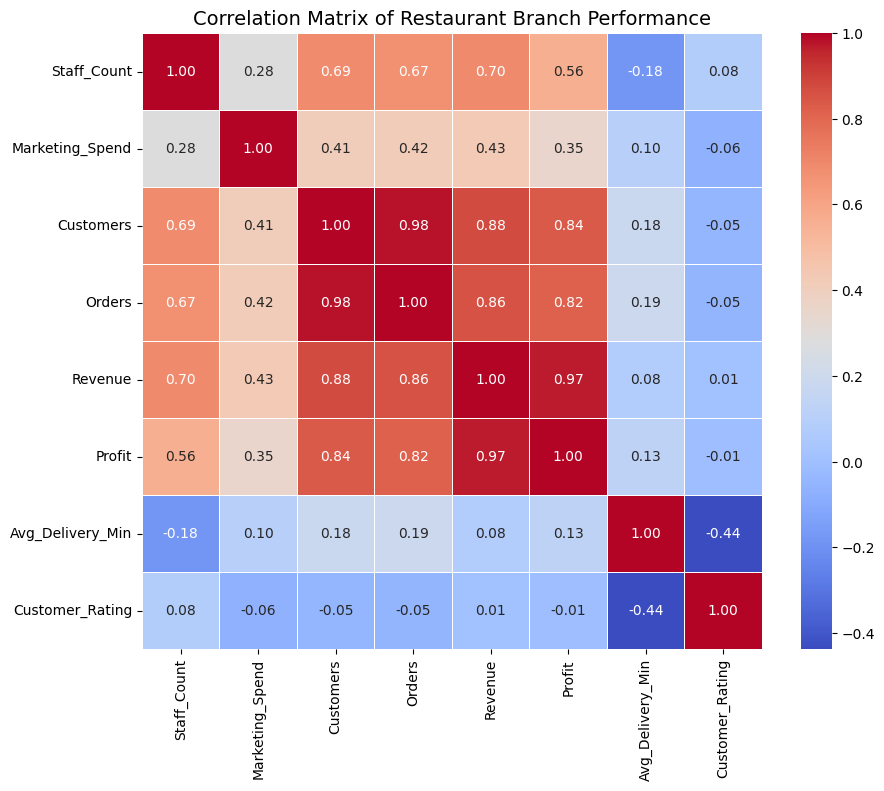

In [4]:
# Compute correlation matrix for numerical variables
numeric_vars = ['Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Revenue', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating']
corr_matrix = df[numeric_vars].corr()

# Plot Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Restaurant Branch Performance", fontsize=14)
plt.show()

###Visualizations (Distribution & Branch Comparison)

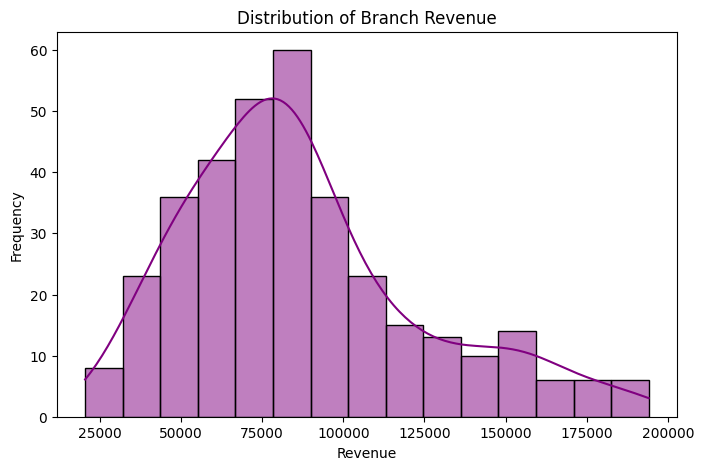

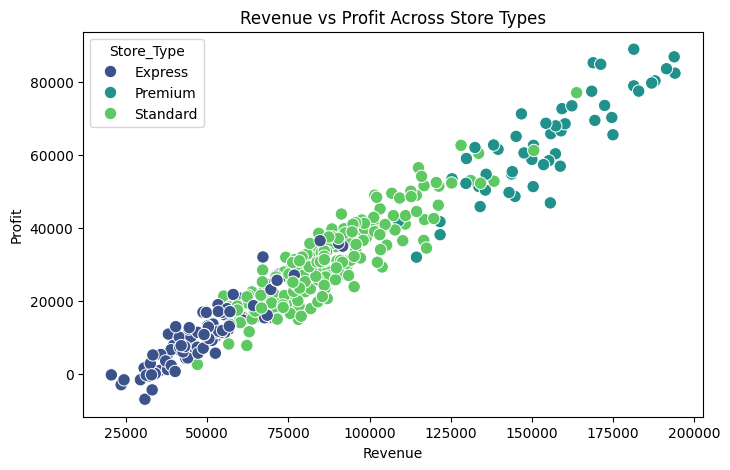

In [5]:
# Revenue Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(df['Revenue'], kde=True, color='purple')
plt.title("Distribution of Branch Revenue", fontsize=12)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# Revenue vs Profit by Store Type
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Revenue', y='Profit', hue='Store_Type', palette='viridis', s=80)
plt.title("Revenue vs Profit Across Store Types", fontsize=12)
plt.show()

In [7]:
# Export the restaurant branch performance dataset to a new CSV file
output_file = "Processed_Restaurant_Branch_Performance.csv"
df.to_csv(output_file, index=False)
print(f"Dataset successfully exported to '{output_file}'!")

Dataset successfully exported to 'Processed_Restaurant_Branch_Performance.csv'!


Key Data-Driven Observations

Strong Revenue-Profit Alignment: There is a near-perfect positive correlation between Revenue and Profit ($r = 0.97$), indicating that operational and food costs scale proportionately across branches without unexpected margin erosion.

Customer Footfall Driver: Customers and Orders show an exceptionally strong correlation ($r = 0.98$), confirming that customer volume is the primary determinant of branch transaction counts.

Delivery Impact on Ratings: A moderate negative correlation ($r = -0.44$) exists between Avg_Delivery_Min and Customer_Rating, highlighting that faster delivery times directly improve customer satisfaction scores.

Regional Performance Leaders: The South and North regions generate the highest aggregate revenue compared to the West, driven by higher customer traffic densities.

Store Type Efficiency: Standard and Premium store formats yield higher total revenue and profit contributions compared to Express branches, supported by larger staff counts and broader customer seating capacities.

Marketing Spend ROI: While marketing expenditure shows a moderate positive correlation with revenue ($r = 0.43$), profit margins remain stable, indicating healthy returns on promotional investments.

Staff Capacity Impact: Branch staff count demonstrates a strong positive correlation with customer volume ($r = 0.69$), showing that adequate staffing is crucial for handling peak service demand.